<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

🔹 **Задание 1. Первичный анализ данных**

1. Загрузите файл в датафрейм и выведите первые 5 строк (Подсказка: найти в документации pandas, как читать csv файл, выставить разделителем запятую).
2. Первый столбец - индекс, который перезаписался как отдельный столбец: удалите его
3. Определите и выведите:

* количество строк и столбцов

* типы данных

* общую информацию по таблице и краткую статистику по числовым столбцам

* минимальное и максимальное значение по мировым сборам

* уникальные жанры

* количество фильмов по каждому рейтингу

In [2]:
df=pd.read_csv('Movies.csv')
df = df.drop(["Unnamed: 0"], axis=1).reset_index(drop=True)
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,"December 16, 2015",936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,"April 24, 2019",858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,"December 16, 2009",760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaN,700426566,647171407,1347597973,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,NaN
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaN,678815482,1369544272,2048359754,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,NaN


In [3]:
df.shape

(918, 10)

In [4]:
df.dtypes

Title                         object
Movie Info                    object
Distributor                   object
Release Date                  object
Domestic Sales (in $)          int64
International Sales (in $)     int64
World Sales (in $)             int64
Genre                         object
Movie Runtime                 object
License                       object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Title                       918 non-null    object
 1   Movie Info                  918 non-null    object
 2   Distributor                 918 non-null    object
 3   Release Date                800 non-null    object
 4   Domestic Sales (in $)       918 non-null    int64 
 5   International Sales (in $)  918 non-null    int64 
 6   World Sales (in $)          918 non-null    int64 
 7   Genre                       918 non-null    object
 8   Movie Runtime               918 non-null    object
 9   License                     744 non-null    object
dtypes: int64(3), object(7)
memory usage: 71.8+ KB


In [6]:
df.describe()

,Domestic Sales (in $),International Sales (in $),World Sales (in $)
count,9.180000e+02,9.180000e+02,9.180000e+02
mean,1.677469e+08,2.301434e+08,3.968668e+08
std,1.040360e+08,2.176011e+08,3.082629e+08
min,8.036084e+07,2.600000e+02,8.160000e+07
25%,1.016071e+08,8.845620e+07,2.005564e+08
50%,1.321351e+08,1.638819e+08,3.019416e+08
75%,1.913905e+08,2.885577e+08,4.750718e+08
max,9.366622e+08,2.086739e+09,2.847246e+09


In [7]:
df["International Sales (in $)"].min()

260

In [8]:
df["International Sales (in $)"].max()

2086738578

In [9]:
df["Distributor"].unique()

array(['Walt Disney Studios Motion Pictures', 'Twentieth Century Fox',
       'Sony Pictures Entertainment (SPE)', 'Paramount Pictures',
       'Universal Pictures', 'Warner Bros.', 'DreamWorks Distribution',
       'Lionsgate', 'DreamWorks', 'New Line Cinema', 'Newmarket Films',
       'Summit Entertainment', 'Columbia Pictures', 'IFC Films',
       'TriStar Pictures', 'Orion Pictures', 'Metro-Goldwyn-Mayer (MGM)',
       'Miramax', 'The Weinstein Company', 'Fox Searchlight Pictures',
       'Revolution Studios', 'Artisan Entertainment',
       'Sony Pictures Classics', 'United Artists', 'Screen Gems',
       'USA Films', '20th Century Studios', 'STX Entertainment',
       'Dimension Films', 'United Artists Releasing', 'FilmDistrict',
       'Focus Features', 'Relativity Media', 'Roadside Attractions'],
      dtype=object)

In [10]:
df["License"].value_counts()

License
PG-13    363
R        194
PG       173
G         14
Name: count, dtype: int64

🔹 **Задание 2. Обработка пропусков и создание новых признаков**

1. Проверьте, в каких столбцах есть пропуски.
2. Замените пропуски в столбце с рейтингом на самое частотное значение (Подсказка: заменить на mode()[0]).
3. Удалите все строки с пропусками в дате релиза.
3. Добавьте новый столбец: доля домашних сборов относительно мировых.

In [11]:
df.isna().sum()

Title                           0
Movie Info                      0
Distributor                     0
Release Date                  118
Domestic Sales (in $)           0
International Sales (in $)      0
World Sales (in $)              0
Genre                           0
Movie Runtime                   0
License                       174
dtype: int64

In [12]:
df["License"]=df["License"].fillna(df["License"].mode()[0])
df.isnull().sum()

Title                           0
Movie Info                      0
Distributor                     0
Release Date                  118
Domestic Sales (in $)           0
International Sales (in $)      0
World Sales (in $)              0
Genre                           0
Movie Runtime                   0
License                         0
dtype: int64

In [13]:
df=df.dropna()
df.isnull().sum()

Title                         0
Movie Info                    0
Distributor                   0
Release Date                  0
Domestic Sales (in $)         0
International Sales (in $)    0
World Sales (in $)            0
Genre                         0
Movie Runtime                 0
License                       0
dtype: int64

In [14]:
df.insert(10, "Dom/Int", df["Domestic Sales (in $)"] / df["International Sales (in $)"])

In [15]:
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Dom/Int
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,"December 16, 2015",936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,0.826812
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,"April 24, 2019",858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,0.442659
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,"December 16, 2009",760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,0.364448
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,"December 19, 1997",659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,0.427525
7,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,"June 10, 2015",652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,0.640768


🔹 **Задание 3. Работа с датами**

1. Преобразуйте столбец Release Date в тип datetime (Подсказка: найти в документации pandas, как вызывать функцию to_datetime).
2. Добавьте новый столбец Year, извлекая из даты только год (Подсказка: найти в документации pandas, как вызывать функцию dt.year).

In [16]:
df["Release Date"]=pd.to_datetime(df["Release Date"])

In [17]:
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Dom/Int
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,0.826812
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,0.442659
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,0.364448
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,0.427525
7,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,0.640768


In [18]:
 df.insert(10,"Year", df["Release Date"].dt.year)
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Year,Dom/Int
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,2015,0.826812
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,2019,0.442659
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,2009,0.364448
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,1997,0.427525
7,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,2015,0.640768


🔹 **Задание 4. Фильтрация данных и срезы**

1. Найдите и выведите фильмы с 10 по 20 строку:

* с домашними сборами больше 70 миллионов (только столбцы с названиями фильмов и домашними сборами)

* со мстителями (в названии есть "Avengers") (только столбцы с названиями фильмов и описанием)

* 20-ого века и студии Paramount Pictures (только столбцы с названиями фильмов, годом и студией)

2. Отсортируйте и пересохраните таблицу в порядке убывания мировых сборов.

In [19]:
df[df['Domestic Sales (in $)'] > 70000000][['Title', 'Domestic Sales (in $)']].iloc[9:19]

,Title,Domestic Sales (in $)
13,Rogue One: A Star Wars Story (2016),532177324
14,Star Wars: Episode IX - The Rise of Skywalker ...,515202542
15,Beauty and the Beast (2017),504481165
17,Frozen II (2019),477373578
18,Star Wars: Episode I - The Phantom Menace (1999),474544677
19,Star Wars: Episode IV - A New Hope (1977),460998507
20,Avengers: Age of Ultron (2015),459005868
21,The Dark Knight Rises (2012),448139099
22,Shrek 2 (2004),441226247
23,E.T. the Extra-Terrestrial (1982),435110554


In [20]:
df.loc[df['Title'].str.contains("Avengers"),['Title', 'Movie Info']]

,Title,Movie Info
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...
8,The Avengers (2012),Earth's mightiest heroes must come together an...
20,Avengers: Age of Ultron (2015),When Tony Stark and Bruce Banner try to jump-s...


In [21]:
df[df['Distributor'].isin(["Twentieth Century Fox","Paramount Pictures"])][['Title', 'Year','Distributor']].iloc[9:19]

,Title,Year,Distributor
77,Indiana Jones and the Kingdom of the Crystal S...,2008,Paramount Pictures
80,Iron Man 2 (2010),2010,Paramount Pictures
81,Star Wars: Episode II - Attack of the Clones (...,2002,Twentieth Century Fox
83,Star Wars: Episode VI - Return of the Jedi (1983),1983,Twentieth Century Fox
84,Independence Day (1996),1996,Twentieth Century Fox
94,Star Wars: Episode V - The Empire Strikes Back...,1980,Twentieth Century Fox
102,Home Alone (1990),1990,Twentieth Century Fox
122,Star Trek (2009),2009,Paramount Pictures
133,Indiana Jones and the Raiders of the Lost Ark ...,1981,Paramount Pictures
135,Transformers: Age of Extinction (2014),2014,Paramount Pictures


In [22]:
df.sort_values("World Sales (in $)",ascending=False)

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Year,Dom/Int
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,2009,0.364448
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,2019,0.442659
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,1997,0.427525
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,2015,0.826812
7,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,2015,0.640768
...,...,...,...,...,...,...,...,...,...,...,...,...
783,Think Like a Man (2012),Four friends conspire to turn the tables on th...,Screen Gems,2012-04-20,91547205,4523302,96070507,"['Comedy', 'Romance']",2 hr 3 min,PG-13,2012,20.239021
848,Anchorman: The Legend of Ron Burgundy (2004),Ron Burgundy is San Diego's top-rated newsman ...,DreamWorks Distribution,2004-07-09,85288303,5421064,90709367,['Comedy'],1 hr 34 min,PG-13,2004,15.732761
831,The Naked Gun 2½: The Smell of Fear (1991),Lieutenant Frank Drebin discovers that his ex-...,Paramount Pictures,1991-06-28,86930411,86930411,86930411,"['Comedy', 'Crime']",1 hr 25 min,PG-13,1991,1.000000
874,I Can Only Imagine (2018),The inspiring and unknown true story behind Me...,Roadside Attractions,2018-03-15,83482352,2604529,86086881,"['Biography', 'Drama', 'Family', 'Music']",1 hr 50 min,PG,2018,32.052763


🔹 **Задание 5. Группировка, агрегация и визуализация**

1. Создайте таблицу с группировкой: сколько фильмов вышло в каждом году.
2. Постройте график по этим данным с:
* подписями осей
* названием графика
* сеткой

3. Создайте таблицу с двойной группировкой: сколько суммарно общемировых сборов собрала каждая студия, сколько фильмов каждая студия сняла.
4. Постройте сабплоты: две столбчатые диаграммы друг под другом по этим данным с:
* размером фигуры 12 * 12
* подписями осей
* названием графика
* цветовой палитрой
* повернутыми на 90 градусов лейблами на оси X
* перед выводом графика добавьте plt.tight_layot(), чтобы графики не накладывались друг на друга

In [23]:
table_group=df.groupby("Year")["Title"].count().reset_index()
table_group.head()

,Year,Title
0,1972,1
1,1975,1
2,1977,1
3,1978,2
4,1979,2


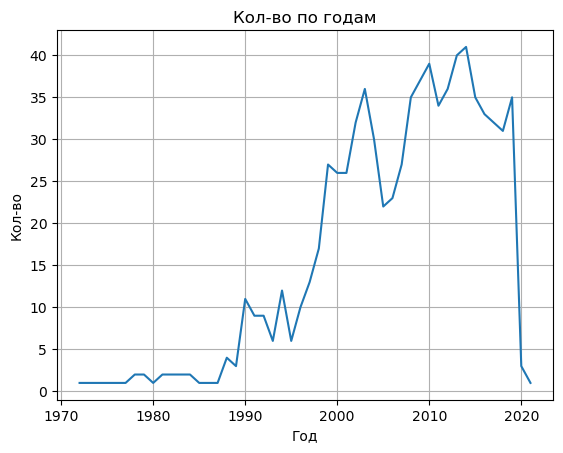

In [24]:
plt.figure()
plt.plot(table_group["Year"], # ось X
         table_group["Title"]# ось Y
         )

plt.title("Кол-во по годам")
plt.xlabel("Год")
plt.ylabel("Кол-во")
plt.grid(True) # добавляем сетку
plt.show()

In [25]:
table_group_2=df.groupby('Distributor').agg(
    big_money=('World Sales (in $)', 'sum'),
    movies_count=('Title', 'count'),
).reset_index()
table_group_2.head()

,Distributor,big_money,movies_count
0,Artisan Entertainment,248639099,1
1,Columbia Pictures,1288912626,6
2,Dimension Films,1223005113,7
3,DreamWorks,9917749677,19
4,DreamWorks Distribution,5272576107,16


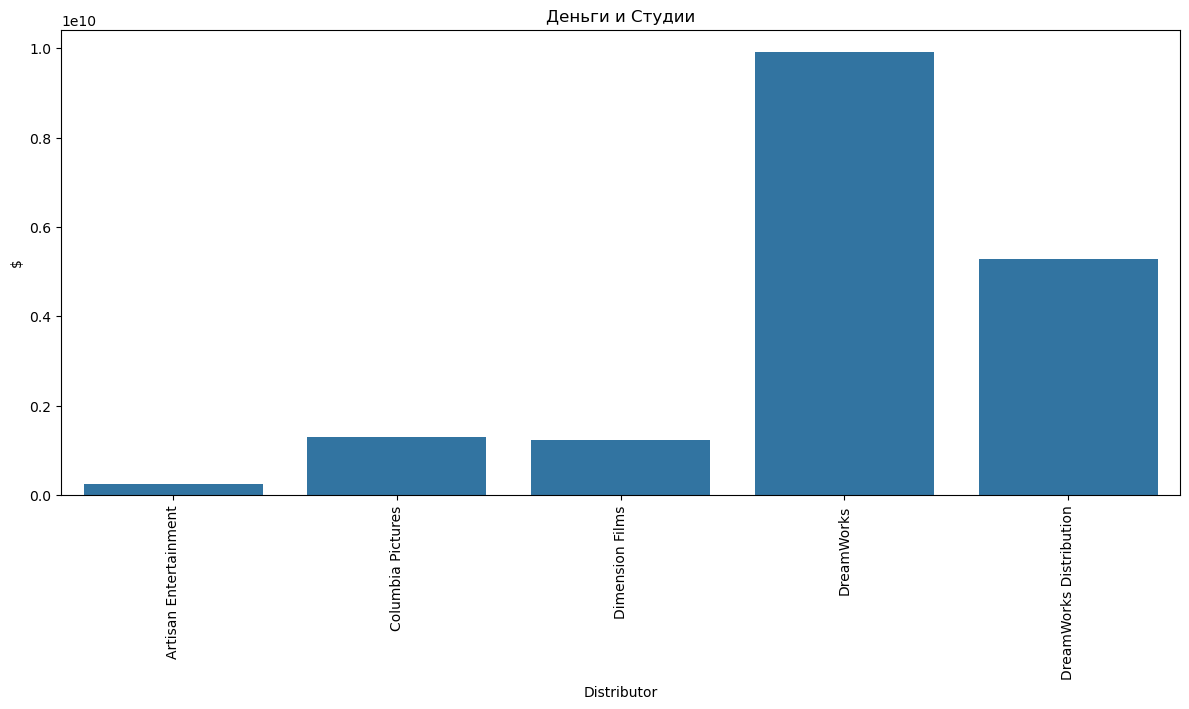

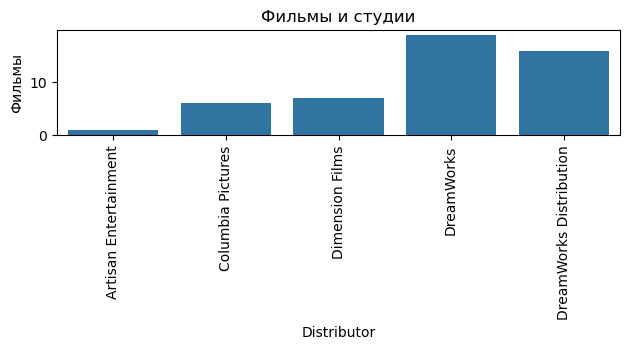

In [26]:
plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)

sns.barplot(data=table_group_2.head(), x="Distributor", y="big_money")
plt.title("Деньги и Студии")
plt.ylabel("$")
plt.xticks(rotation=90) 
plt.tight_layout() 
plt.show()

plt.subplot(2, 1, 2)

sns.barplot(data=table_group_2.head(), x="Distributor", y="movies_count")
plt.title("Фильмы и студии")
plt.ylabel("Фильмы")
plt.xticks(rotation=90)
plt.tight_layout() 
plt.show()

🔹 **Задание 6. Кастомные функции и применение apply()**

1. Напишите функцию movie_runtime_minutes, которая переведет длительность фильмов из текстового формата в минуты:
* как один из вариантов, можно найти оба числа, то есть часы и минуты, с помощью re.findall("[0-9]{1, }", x), не забыв импортировать библиотеку re
* сохранить это как список, затем умножить первое число (час) из списка на 60, прибавить второе число (минуты): не забыть учесть, что не во всех фильмах указаны минуты - значит, нужно прописать отдельные условия, если есть и часы, и минуты, или есть только часы
* не забыть, что элементы в списке - строковые, нужно перевести их в числа: условно будет int(numbers[0])*60 + ...
2. Примените функцию к таблице, создав новый столбец Movie Runtime Minutes.

In [27]:
def movie_runtime_minutes(runtime_str):
    if pd.isna(runtime_str) or runtime_str == '':
        return None
    # Ищем все числа в строке
    numbers = re.findall(r"[0-9]+", runtime_str)
    numbers = [int(num) for num in numbers]
    
    # Определяем формат на основе количества найденных чисел
    if len(numbers) == 2:
        # Есть и часы, и минуты (например, "2 hr 42 min")
        hours, minutes = numbers
        return hours * 60 + minutes
    elif len(numbers) == 1:
        # Только одно число - проверяем контекст
        if 'hr' in runtime_str.lower():
            # Только часы (например, "2 hr")
            return numbers[0] * 60
        elif 'min' in runtime_str.lower():
            # Только минуты
            return numbers[0]
    else:
        # Более 2 чисел - берем первые два как часы и минуты
        return numbers[0] * 60 + numbers[1]

# Применяем функцию к таблице
df['Movie Runtime Minutes'] = df['Movie Runtime'].apply(movie_runtime_minutes)
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Year,Dom/Int,Movie Runtime Minutes
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,2015,0.826812,138
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,2019,0.442659,181
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,2009,0.364448,162
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,1997,0.427525,194
7,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,2015,0.640768,124


🔹 **Задание 7. Визуализация корреляций**

1. Выведите корреляционную матрицу по числовым признакам в таблице.
2. Постройте тепловую карту по этим данным с названием графика.
3. Напишите в отдельной ячейке markdown, есть ли взаимосвязь между продолжительностью фильма и его сборами?
4. Постройте диаграмму рассеяния между признаками, у которых наибольшая корреляция (Подсказка: в документации найдите matplotlib scatter, какие обязательные параметры туда нужно передать).
5. Сохраните итоговую таблицу в excel.

In [31]:
def runtime_to_minutes(runtime_str):
    if isinstance(runtime_str, str):
        hours = 0
        minutes = 0
        if 'hr' in runtime_str:
            hours_part = runtime_str.split('hr')[0].strip()
            hours = int(hours_part)
        if 'min' in runtime_str:
            min_part = runtime_str.split('min')[0].strip()
            if 'hr' in min_part:
                min_part = min_part.split('hr')[1].strip()
            minutes = int(min_part)
        return hours * 60 + minutes
    return 0

df['Movie Runtime Minutes'] = df['Movie Runtime'].apply(runtime_to_minutes)
df[['Title', 'Movie Runtime', 'Movie Runtime Minutes']].head()

,Title,Movie Runtime,Movie Runtime Minutes
0,Star Wars: Episode VII - The Force Awakens (2015),2 hr 18 min,138
1,Avengers: Endgame (2019),3 hr 1 min,181
2,Avatar (2009),2 hr 42 min,162
6,Titanic (1997),3 hr 14 min,194
7,Jurassic World (2015),2 hr 4 min,124


In [32]:
numeric_columns = [
    'Domestic Sales (in $)', 
    'International Sales (in $)', 
    'World Sales (in $)', 
    'Dom/Int', 
    'Year', 
    'Movie Runtime Minutes'
]

correlation_matrix = df[numeric_columns].corr()

print("Корреляционная матрица:")
correlation_matrix

Корреляционная матрица:


,Domestic Sales (in $),International Sales (in $),World Sales (in $),Dom/Int,Year,Movie Runtime Minutes
Domestic Sales (in $),1.000000,0.792538,0.901854,-0.021281,0.094280,0.274970
International Sales (in $),0.792538,1.000000,0.977177,-0.038940,0.247533,0.323467
World Sales (in $),0.901854,0.977177,1.000000,-0.034759,0.210808,0.322855
Dom/Int,-0.021281,-0.038940,-0.034759,1.000000,-0.099847,0.025984
Year,0.094280,0.247533,0.210808,-0.099847,1.000000,-0.004841
Movie Runtime Minutes,0.274970,0.323467,0.322855,0.025984,-0.004841,1.000000


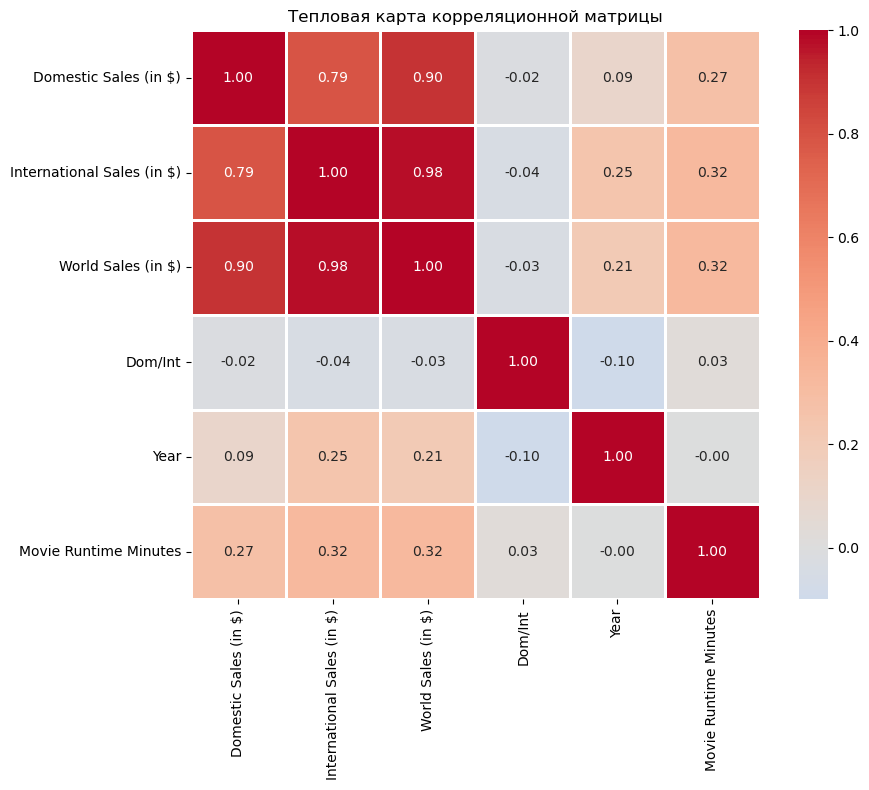

In [33]:
# Тепловая карта корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=1,
            linecolor='white',
            fmt='.2f')
plt.title('Тепловая карта корреляционной матрицы')
plt.tight_layout()
plt.show()

Вывод: взаимосвязь между продолжительностью и сборами значима, но не критична - примерно 0,3

Наибольшая корреляция: 0.9772 между 'World Sales (in $)' и 'International Sales (in $)'


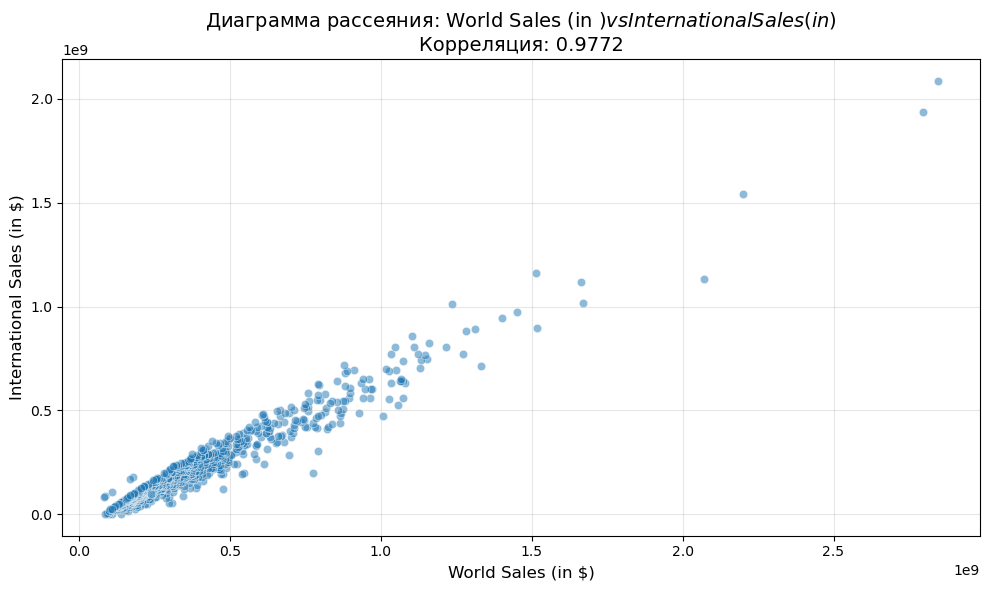


Итоговая таблица сохранена в файл: movies_final_analysis.xlsx


In [34]:
# Исключаем диагональные значения 
corr_without_diag = correlation_matrix.copy()
for col in corr_without_diag.columns:
    corr_without_diag.loc[col, col] = 0

# Находим максимальную корреляцию
max_corr = corr_without_diag.max().max()
max_corr_pair = None

for col1 in correlation_matrix.columns:
    for col2 in correlation_matrix.columns:
        if col1 != col2 and correlation_matrix.loc[col1, col2] == max_corr:
            max_corr_pair = (col1, col2)

print(f"Наибольшая корреляция: {max_corr:.4f} между '{max_corr_pair[0]}' и '{max_corr_pair[1]}'")

# Строим диаграмму рассеяния для этих признаков
plt.figure(figsize=(10, 6))
plt.scatter(df[max_corr_pair[0]], 
            df[max_corr_pair[1]], 
            alpha=0.5, 
            edgecolors='w', 
            linewidth=0.5)

plt.xlabel(max_corr_pair[0], fontsize=12)
plt.ylabel(max_corr_pair[1], fontsize=12)
plt.title(f'Диаграмма рассеяния: {max_corr_pair[0]} vs {max_corr_pair[1]}\nКорреляция: {max_corr:.4f}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Сохраняем 
output_file = 'movies_final_analysis.xlsx'
df.to_excel(output_file, index=False)
print(f"\nИтоговая таблица сохранена в файл: {output_file}")